# Multiple Linear Regression From Scratch — Predicting Sales

## Problem Statement

We revisit the **Advertising** dataset — 200 markets, with money spent on `TV`, `Radio`, and `Newspaper` advertising, and the resulting `Sales`.

This time, instead of using a single feature, we use **all three advertising channels together** to predict Sales. This is called **Multiple Linear Regression**:

$$\hat{y} = b_0 + w_1 x_1 + w_2 x_2 + w_3 x_3$$

where `x1 = TV`, `x2 = Radio`, `x3 = Newspaper`.

**What we'll do in this notebook:**
1. Explore the data (with visualizations)
2. Implement Multiple Linear Regression **from scratch** using vectorized Gradient Descent
3. Perform **hyperparameter tuning** — experiment with different learning rates and epoch counts
4. Solve the same problem using `scikit-learn`
5. Compare both approaches — coefficients, predictions, and error metrics — with plots

**Dataset:** `Advertising.csv` (the same one from the earlier Simple Linear Regression notebook)

## Step 1: Import Libraries

- `pandas`, `numpy` for data handling
- `matplotlib.pyplot`, `seaborn` for visualization
- From `sklearn.model_selection`, import `train_test_split`
- From `sklearn.linear_model`, import `LinearRegression`
- From `sklearn.metrics`, import `mean_squared_error`, `mean_absolute_error`, `r2_score`

In [9]:
# TODO: write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

## Step 2: Load and Explore the Data

- Read `Advertising.csv` into `df` (set `index_col=0`, since the first column is just a row index)
- Check `head()`, `shape`, `info()`, `describe()`
- Check for missing values

In [10]:
# TODO: write your code here
df=pd.read_csv('Advertising.csv',index_col=0)
df.head()


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [11]:
df.shape

(200, 4)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [13]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## Step 3: Exploratory Data Analysis — Visualize Everything

- Plot a **pairplot** of all columns (`sns.pairplot`) to see pairwise relationships
- Plot a **correlation heatmap** (`df.corr()` + `sns.heatmap(annot=True)`) to see which feature correlates most strongly with `Sales`
- Plot individual scatter plots of each feature (`TV`, `Radio`, `Newspaper`) against `Sales`, side by side

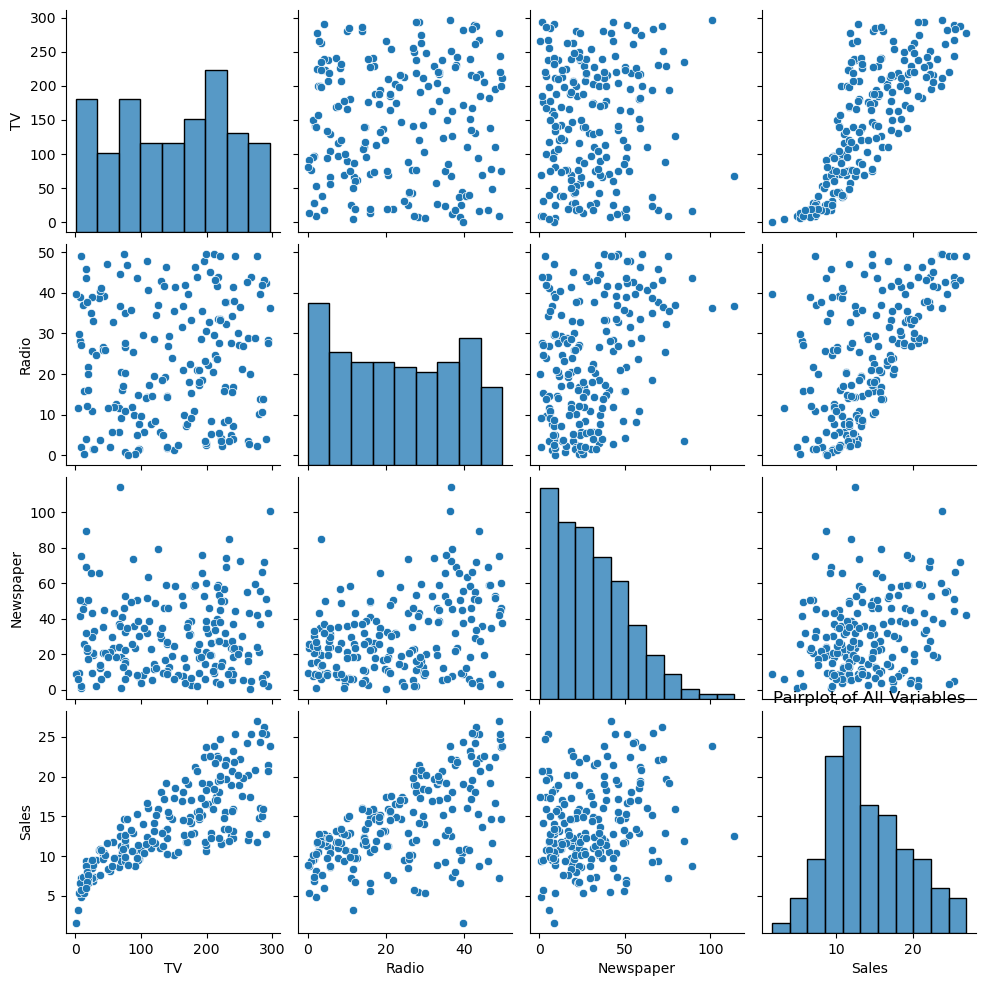

In [14]:
# TODO: write your code here
sns.pairplot(df)
plt.title("Pairplot of All Variables")  
plt.show()

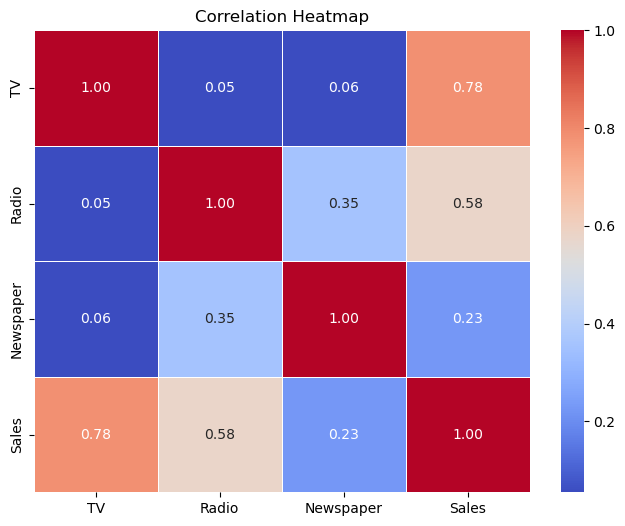

In [17]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True) 
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


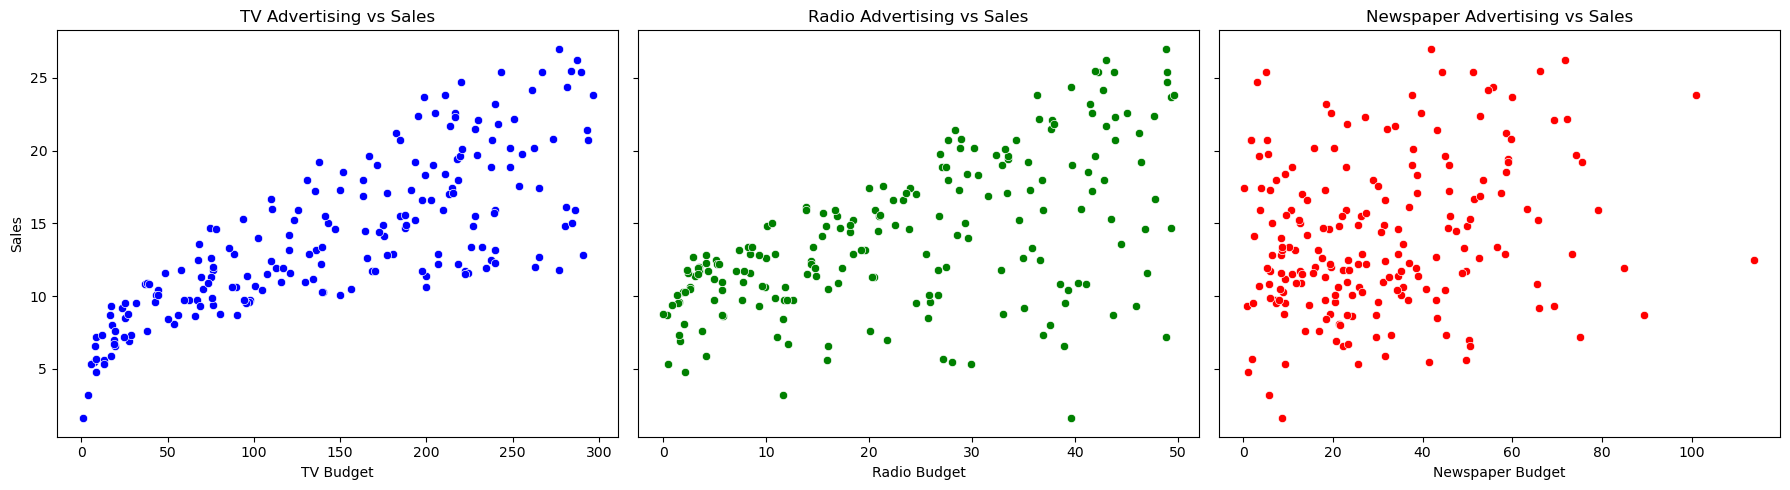

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# TV vs Sales
sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0], color="blue")
axes[0].set_title("TV Advertising vs Sales")
axes[0].set_xlabel("TV Budget")
axes[0].set_ylabel("Sales")

# Radio vs Sales
sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1], color="green")
axes[1].set_title("Radio Advertising vs Sales")
axes[1].set_xlabel("Radio Budget")

# Newspaper vs Sales
sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2], color="red")
axes[2].set_title("Newspaper Advertising vs Sales")
axes[2].set_xlabel("Newspaper Budget")

plt.tight_layout()
plt.show()

### What do you observe?

Look at the correlation heatmap and scatter plots above, and note (in a markdown cell or comment):
- Which feature seems to have the *strongest* linear relationship with Sales?
- Which feature seems to have the *weakest* relationship?

*(Hint: this will help you sanity-check the coefficients your model produces later.)*

## Step 4: Prepare Features and Target

- `X = df[['TV', 'Radio', 'Newspaper']].values` (as a numpy array)
- `y = df['Sales'].values`

In [19]:
# TODO: write your code here

X = df[["TV", "Radio", "Newspaper"]].values
y = df["Sales"].values


print(f"X shape (Features): {X.shape}")
print(f"y shape (Target): {y.shape}")


X shape (Features): (200, 3)
y shape (Target): (200,)


## Step 5: Train-Test Split

- Split `X, y` using `train_test_split()` with `test_size=0.2, random_state=42`
- Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`

In [20]:
# TODO: write your code here

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (160, 3)
X_test shape:  (40, 3)
y_train shape: (160,)
y_test shape:  (40,)


## Step 6: Feature Scaling (Standardization)

`TV`, `Radio`, and `Newspaper` are on very different scales (TV budgets go up to ~300, Radio and Newspaper are much smaller). For Gradient Descent to converge smoothly and quickly, we should **standardize** every feature:

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

**Important:** Compute the mean (`μ`) and standard deviation (`σ`) using only the **training data**, then apply the *same* mean/std to the test data. This avoids leaking information from the test set into training.

- Compute `X_mean` and `X_std` from `X_train` (use `axis=0` so you get one mean/std per column)
- Create `X_train_scaled` and `X_test_scaled` using these training statistics

In [22]:
# TODO: write your code here
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)


X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

print("Verification - Training Scaled Means (should be close to 0):", np.round(X_train_scaled.mean(axis=0), 2))
print("Verification - Training Scaled Stds (should be exactly 1): ", np.round(X_train_scaled.std(axis=0), 2))

Verification - Training Scaled Means (should be close to 0): [-0.  0.  0.]
Verification - Training Scaled Stds (should be exactly 1):  [1. 1. 1.]


## Step 7: The Maths of Multiple Linear Regression (Vectorized)

With multiple features, we write the model using vectors/matrices instead of scalars:

$$\hat{y} = Xw + b$$

where `X` is the (n_samples × n_features) matrix, `w` is a vector of weights (one per feature), and `b` is a single intercept.

**Cost function (Mean Squared Error):**

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

**Gradients (vectorized — no need to loop over features one at a time):**

$$\frac{\partial MSE}{\partial w} = \frac{2}{n} X^T (\hat{y} - y) \qquad \frac{\partial MSE}{\partial b} = \frac{2}{n}\sum(\hat{y} - y)$$

**Update rule (same idea as Simple Linear Regression, just with vectors now):**

$$w := w - \alpha \cdot \frac{\partial MSE}{\partial w} \qquad b := b - \alpha \cdot \frac{\partial MSE}{\partial b}$$

## Step 8: Implement Gradient Descent From Scratch (as a Reusable Function)

Write a function `train_gradient_descent(X, y, learning_rate, epochs)` that:
- Initializes `w` as a zero vector of length `X.shape[1]`, and `b = 0`
- Loops for the given number of `epochs`:
  - Computes predictions `y_pred = X.dot(w) + b`
  - Computes the error `y_pred - y`
  - Computes gradients `dw` and `db` using the vectorized formulas above
  - Updates `w` and `b`
  - Records the MSE for this epoch in a list (`cost_history`)
- Returns `w`, `b`, and `cost_history`

This function will be reused throughout the notebook, including in the hyperparameter tuning section.

In [23]:
# TODO: write your code here

def train_gradient_descent(X, y, learning_rate, epochs):
   
    n_samples, n_features = X.shape

   
    w = np.zeros(n_features)
    b = 0.0
    cost_history = []

 
    for epoch in range(epochs):
        
        y_pred = X.dot(w) + b

       
        error = y_pred - y

        
        mse = np.mean(error**2)
        cost_history.append(mse)

       
        dw = (2 / n_samples) * X.T.dot(error)
        db = (2 / n_samples) * np.sum(error)

       
        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, cost_history



weights, intercept, cost_history = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=0.05, epochs=1000
)

print("--- Final Model Parameters ---")
print(f"Intercept (b): {intercept:.4f}")
print(f"Weights (w):   {np.round(weights, 4)}")
print(f"               [TV: {weights[0]:.4f}, Radio: {weights[1]:.4f}, Newspaper: {weights[2]:.4f}]")


--- Final Model Parameters ---
Intercept (b): 14.1000
Weights (w):   [3.7642 2.7923 0.056 ]
               [TV: 3.7642, Radio: 2.7923, Newspaper: 0.0560]


## Step 9: Train a Baseline Model

- Call `train_gradient_descent()` on `X_train_scaled, y_train` with `learning_rate=0.01` and `epochs=1000`
- Print the final `w`, `b`, and the last value of `cost_history`
- Plot the cost history (loss curve)

--- Baseline Model Results ---
Final Weights (w):   [3.7642 2.7923 0.056 ]
                     [TV: 3.7642, Radio: 2.7923, Newspaper: 0.0560]
Final Intercept (b): 14.1000
Final Cost (MSE):    2.7051



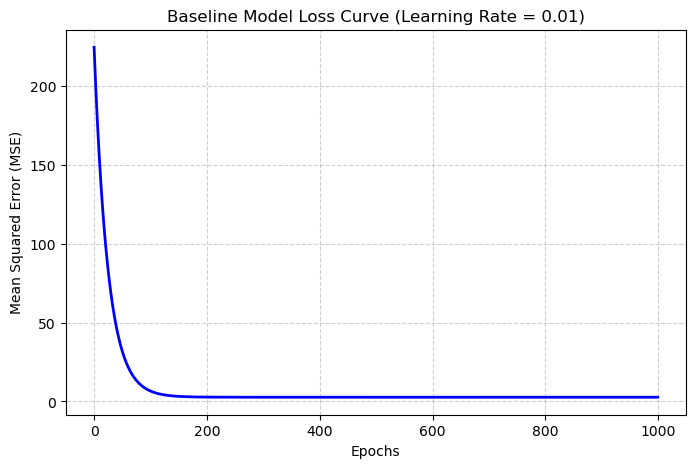

In [25]:
# TODO: write your code here
learning_rate = 0.01
epochs = 1000

w_baseline, b_baseline, cost_history_baseline = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=learning_rate, epochs=epochs
)

print("--- Baseline Model Results ---")
print(f"Final Weights (w):   {np.round(w_baseline, 4)}")
print(f"                     [TV: {w_baseline[0]:.4f}, Radio: {w_baseline[1]:.4f}, Newspaper: {w_baseline[2]:.4f}]")
print(f"Final Intercept (b): {b_baseline:.4f}")
print(f"Final Cost (MSE):    {cost_history_baseline[-1]:.4f}\n")


plt.figure(figsize=(8, 5))
plt.plot(cost_history_baseline, color="blue", linewidth=2)
plt.title("Baseline Model Loss Curve (Learning Rate = 0.01)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Step 10: Convert Weights Back to the Original (Unscaled) Feature Space

Since we trained on standardized features, `w_scratch` and `b_scratch` are in "scaled space." To interpret them in terms of the original units (e.g. "$ of Sales per $1000 of TV spend"), convert them back:

$$w_{original} = \frac{w_{scaled}}{\sigma} \qquad b_{original} = b_{scaled} - \sum \left(\frac{w_{scaled} \cdot \mu}{\sigma}\right)$$

In [27]:
# TODO: write your code here

w_original = w_baseline / X_std
b_original = b_baseline - np.sum((w_baseline * X_mean) / X_std)


print("--- Unscaled (Original Space) Model Parameters ---")
print(f"Original Intercept (b_orig): {b_original:.4f}")
print(f"Original Weights (w_orig):   {np.round(w_original, 4)}")
print(f"                             [TV: {w_original[0]:.4f}, Radio: {w_original[1]:.4f}, Newspaper: {w_original[2]:.4f}]")


--- Unscaled (Original Space) Model Parameters ---
Original Intercept (b_orig): 2.9791
Original Weights (w_orig):   [0.0447 0.1892 0.0028]
                             [TV: 0.0447, Radio: 0.1892, Newspaper: 0.0028]


## Step 11: Hyperparameter Tuning — Learning Rate

Gradient Descent has two key hyperparameters: the **learning rate** and the **number of epochs**. Let's see how the learning rate affects convergence.

- Try `learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]`, each for `epochs=300`
- For each learning rate, call `train_gradient_descent()` on the scaled training data and store the `cost_history`
- Plot all the loss curves on the same chart (one line per learning rate) so you can visually compare how fast (or whether) each one converges
- What happens with `learning_rate=1.0`? Why?

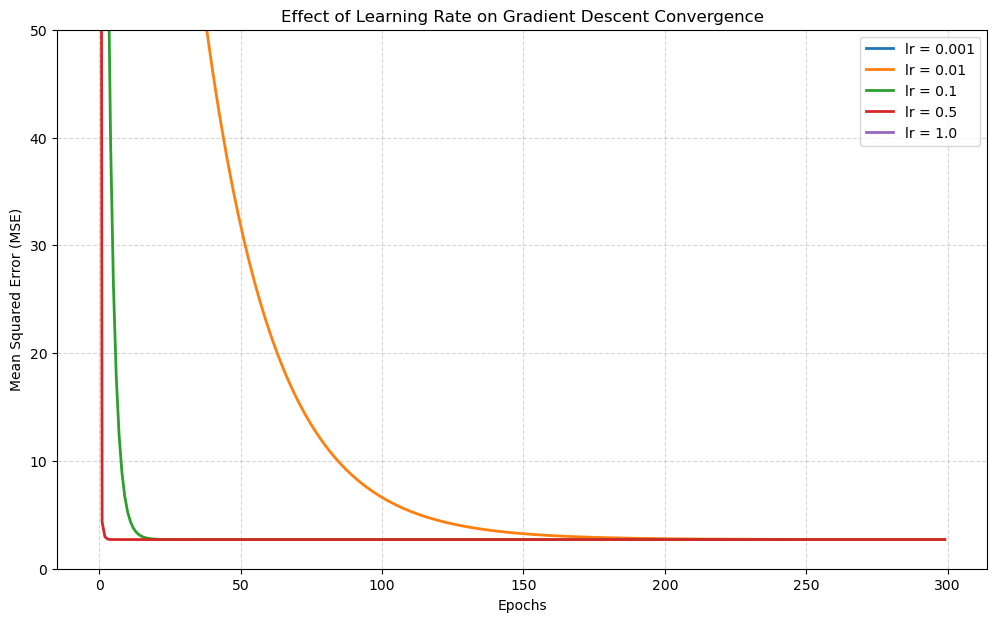

In [42]:
# TODO: write your code here

learning_rates = [0.001,0.01,0.1,0.5,1.0]
epochs = 300

plt.figure(figsize=(12, 7))

for lr in learning_rates:
    _, _, cost_history = train_gradient_descent(
        X_train_scaled, y_train, learning_rate=lr, epochs=epochs
    )

  
    plt.plot(cost_history, label=f"lr = {lr}", linewidth=2)


plt.title("Effect of Learning Rate on Gradient Descent Convergence")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")

plt.ylim(0, 50)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## Step 12: Hyperparameter Tuning — Number of Epochs

Now fix a good learning rate (e.g. `0.1`) and see how the **test set** MSE changes as we increase the number of epochs.

- Try `epoch_options = [10, 50, 100, 300, 500, 1000, 2000]`
- For each value, train the model on `X_train_scaled, y_train`, then evaluate the **test MSE** using `X_test_scaled`
- Plot `epochs` (x-axis) vs `test MSE` (y-axis) to see where the model "levels off" (i.e. where more epochs stop helping)

Epochs:   10 | Test MSE: 5.7978
Epochs:   50 | Test MSE: 3.1749
Epochs:  100 | Test MSE: 3.1741
Epochs:  300 | Test MSE: 3.1741
Epochs:  500 | Test MSE: 3.1741
Epochs: 1000 | Test MSE: 3.1741
Epochs: 2000 | Test MSE: 3.1741


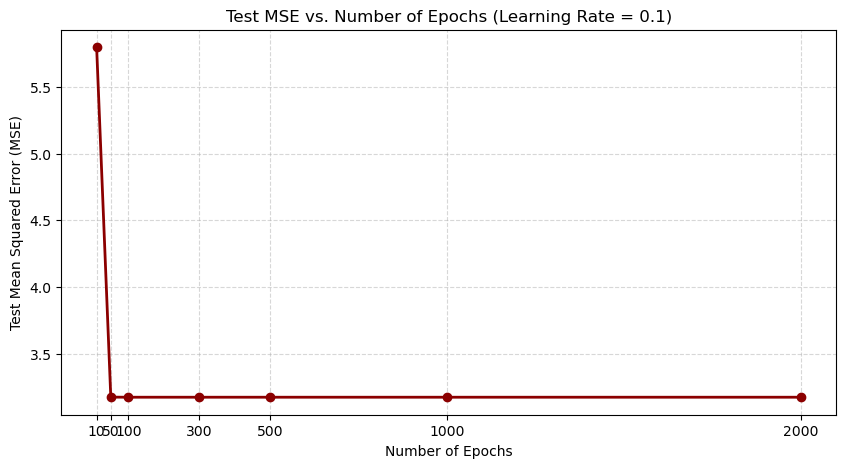

In [29]:
# TODO: write your code here

fixed_lr = 0.1
epoch_options = [10, 50, 100, 300, 500, 1000, 2000]
test_mse_history = []

for epochs in epoch_options:
  
    w, b, _ = train_gradient_descent(
        X_train_scaled, y_train, learning_rate=fixed_lr, epochs=epochs
    )

   
    y_test_pred = X_test_scaled.dot(w) + b

    test_mse = np.mean((y_test_pred - y_test) ** 2)
    test_mse_history.append(test_mse)

    print(f"Epochs: {epochs:4d} | Test MSE: {test_mse:.4f}")


plt.figure(figsize=(10, 5))
plt.plot(
    epoch_options, test_mse_history, marker="o", color="darkred", linewidth=2
)
plt.title(f"Test MSE vs. Number of Epochs (Learning Rate = {fixed_lr})")
plt.xlabel("Number of Epochs")
plt.ylabel("Test Mean Squared Error (MSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(epoch_options)  
plt.show()


## Step 13: Grid Search Over Learning Rate AND Epochs

Combine both hyperparameters into a small **grid search**:

- Try every combination of `learning_rates = [0.001, 0.01, 0.1, 0.5]` and `epoch_options = [100, 500, 1000, 2000]`
- For each combination, train the model and record the **test MSE** in a results table
- Visualize the results as a **heatmap** (learning rate vs epochs, colored by test MSE) — this makes it easy to spot the best region
- Identify and print the single best (learning_rate, epochs) combination (lowest test MSE)

c:\Users\jeeva\anaconda3\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_16208\3720041438.py:21: RuntimeWarning: overflow encountered in square
  mse = np.mean(error**2)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_16208\2610727272.py:16: RuntimeWarning: overflow encountered in square
  test_mse = np.mean((y_test_pred - y_test) ** 2)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_16208\3720041438.py:25: RuntimeWarning: overflow encountered in dot
  dw = (2 / n_samples) * X.T.dot(error)
C:\Users\jeeva\AppData\Local\Temp\ipykernel_16208\3720041438.py:15: RuntimeWarning: invalid value encountered in dot
  y_pred = X.dot(w) + b
C:\Users\jeeva\AppData\Local\Temp\ipykernel_16208\3720041438.py:25: RuntimeWarning: invalid value encountered in dot
  dw = (2 / n_samples) * X.T.dot(error)
c:\Users\jeeva\anaconda3\Lib\site-packages\numpy\_core\fromnume

OPTIMAL HYPERPARAMETERS FOUND
Best Learning Rate: 0.5
Best Epochs:        10
Lowest Test MSE:    3.1740



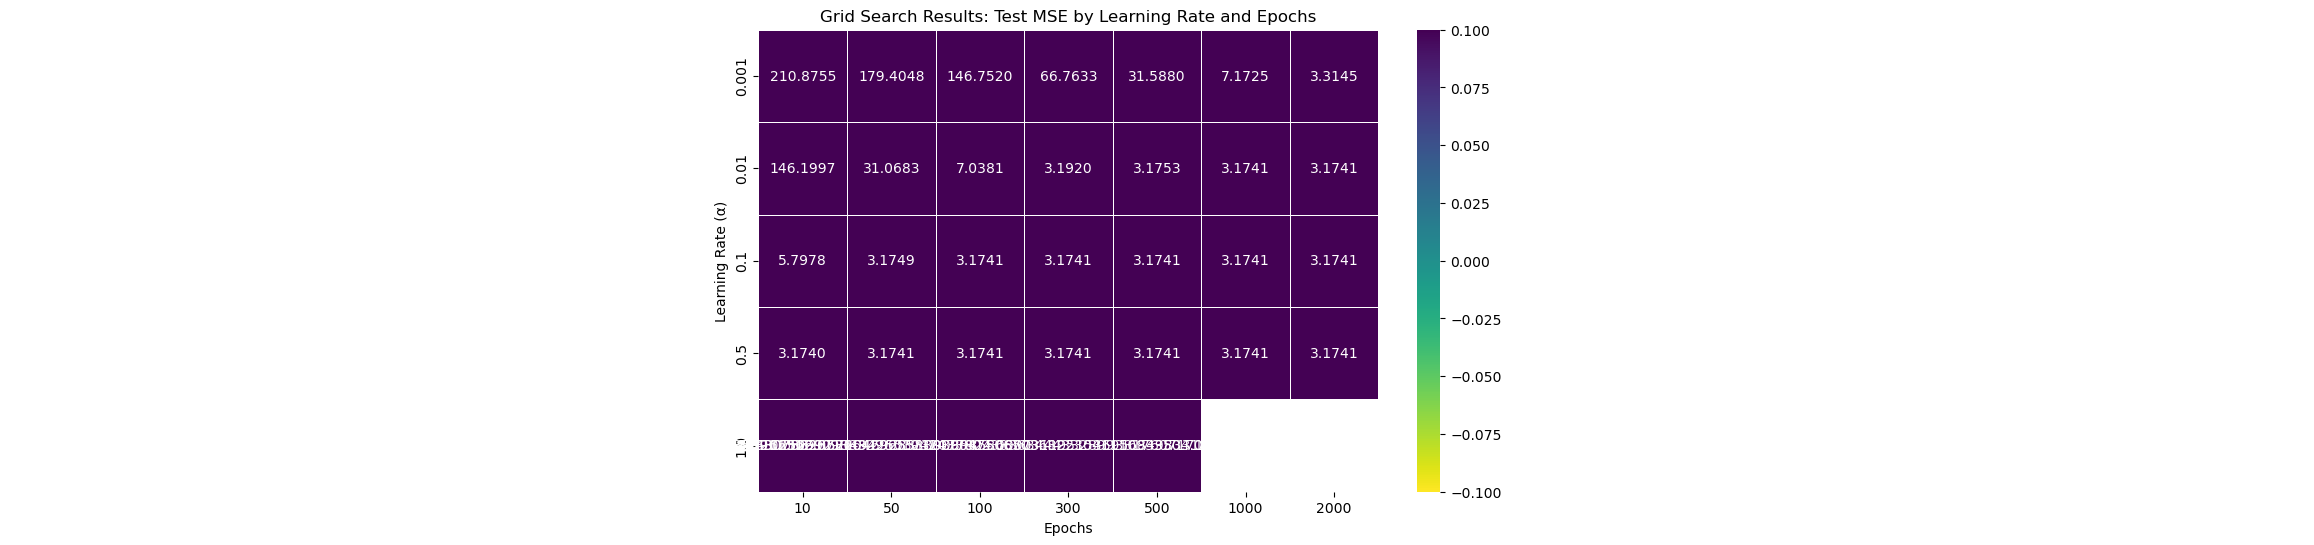

In [30]:
# TODO: write your code he
results = []


for lr in learning_rates:
    for epochs in epoch_options:
     
        w, b, _ = train_gradient_descent(
            X_train_scaled, y_train, learning_rate=lr, epochs=epochs
        )

        # Generate predictions on the scaled test data
        y_test_pred = X_test_scaled.dot(w) + b

        # Compute evaluation metric (Test MSE)
        test_mse = np.mean((y_test_pred - y_test) ** 2)

        # Append configuration and result
        results.append({"Learning Rate": lr, "Epochs": epochs, "Test MSE": test_mse})


df_results = pd.DataFrame(results)
pivot_table = df_results.pivot(
    index="Learning Rate", columns="Epochs", values="Test MSE"
)


best_run = df_results.loc[df_results["Test MSE"].idxmin()]
print("=" * 40)
print("OPTIMAL HYPERPARAMETERS FOUND")
print("=" * 40)
print(f"Best Learning Rate: {best_run['Learning Rate']}")
print(f"Best Epochs:        {int(best_run['Epochs'])}")
print(f"Lowest Test MSE:    {best_run['Test MSE']:.4f}\n")

plt.figure(figsize=(10, 6))
# Using 'viridis_r' so that lower MSE values (better performance) appear darker/more intense
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis_r", linewidths=0.5)
plt.title("Grid Search Results: Test MSE by Learning Rate and Epochs")
plt.ylabel("Learning Rate (α)")
plt.xlabel("Epochs")
plt.show()


## Step 14: Train the Final Model Using the Best Hyperparameters

- Using the best `learning_rate` and `epochs` found in Step 13, retrain the model on `X_train_scaled, y_train`
- Store the final `w_final`, `b_final`, and `cost_history_final`
- Plot the final loss curve

Retraining Final Model (LR: 0.5 | Epochs: 10)
Final Weights (w_final):   [3.7642 2.792  0.0559]
Final Intercept (b_final): 14.1000
Final Training MSE:        2.7051



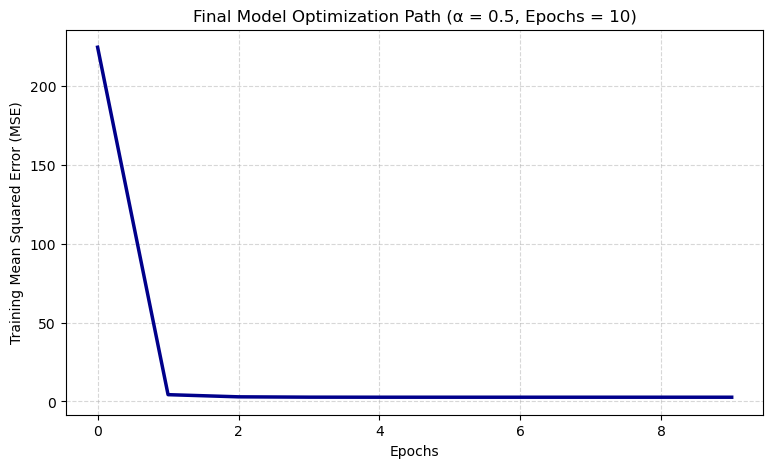

In [31]:
# TODO: write your code here

best_lr = best_run["Learning Rate"]
best_epochs = int(best_run["Epochs"])

print("=" * 50)
print(f"Retraining Final Model (LR: {best_lr} | Epochs: {best_epochs})")
print("=" * 50)

w_final, b_final, cost_history_final = train_gradient_descent(
    X_train_scaled, y_train, learning_rate=best_lr, epochs=best_epochs
)


print(f"Final Weights (w_final):   {np.round(w_final, 4)}")
print(f"Final Intercept (b_final): {b_final:.4f}")
print(f"Final Training MSE:        {cost_history_final[-1]:.4f}\n")


plt.figure(figsize=(9, 5))
plt.plot(cost_history_final, color="darkblue", linewidth=2.5)
plt.title(
    f"Final Model Optimization Path (α = {best_lr}, Epochs = {best_epochs})"
)
plt.xlabel("Epochs")
plt.ylabel("Training Mean Squared Error (MSE)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## Step 15: Evaluate the From-Scratch Model on the Test Set

- Predict on `X_test_scaled` using `w_final, b_final`
- Compute MAE, MSE, RMSE, and R² against `y_test`

In [32]:
# TODO: write your code here

y_pred_test = X_test_scaled.dot(w_final) + b_final
mae = np.mean(np.abs(y_pred_test - y_test))
mse = np.mean((y_pred_test - y_test) ** 2)
rmse = np.sqrt(mse)
ss_residual = np.sum((y_test - y_pred_test) ** 2)
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_residual / ss_total)
print("=" * 45)
print("  FROM-SCRATCH MODEL TEST PERFORMANCE REPORT  ")
print("=" * 45)
print(f"Mean Absolute Error (MAE):    {mae:.4f}")
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²):         {r2:.4f}")
print("=" * 45)


  FROM-SCRATCH MODEL TEST PERFORMANCE REPORT  
Mean Absolute Error (MAE):    1.4607
Mean Squared Error (MSE):     3.1740
Root Mean Squared Error (RMSE): 1.7816
R-squared Score (R²):         0.8994


## Step 16: Visualize Actual vs Predicted, and Residuals

- Scatter plot of `y_test` (x-axis) vs `y_pred_scratch` (y-axis), with a red dashed diagonal reference line (perfect predictions would fall exactly on this line)
- Residual plot: `y_pred_scratch` (x-axis) vs residuals `y_test - y_pred_scratch` (y-axis), with a horizontal line at 0

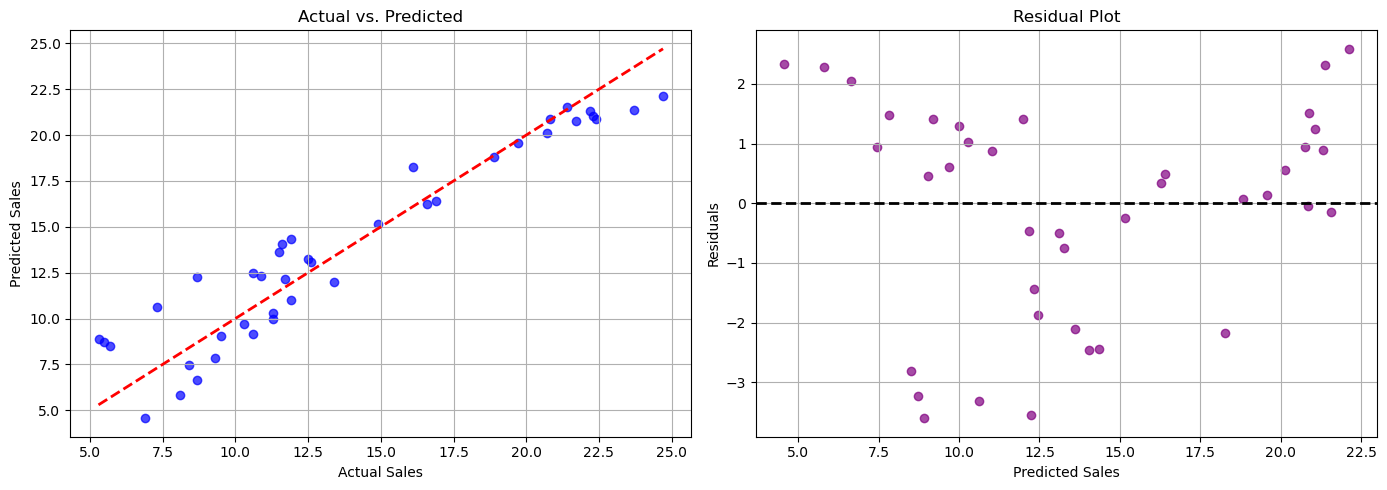

In [33]:
# TODO: write your code here
residuals = y_test - y_pred_test
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, color="blue", alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
)
plt.title("Actual vs. Predicted")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.grid(True)


plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, residuals, color="purple", alpha=0.7)
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.grid(True)

plt.tight_layout()
plt.show()


## Step 17: Solve the Same Problem Using scikit-learn

- Create a `LinearRegression()` model
- Fit it on the **unscaled** `X_train, y_train` (scikit-learn's closed-form solver doesn't need feature scaling)
- Print `lr_model.coef_` and `lr_model.intercept_`, and compare with `w_original` / `b_original` from Step 10

In [34]:
# TODO: write your code here
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("=" * 55)
print("             MODEL PARAMETER COMPARISON             ")
print("=" * 55)
print("--- Scikit-Learn Model (Closed-Form) ---")
print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"Weights:   {np.round(lr_model.coef_, 4)}")
print(f"           [TV: {lr_model.coef_[0]:.4f}, Radio: {lr_model.coef_[1]:.4f}, Newspaper: {lr_model.coef_[2]:.4f}]")
print("-" * 55)
print("--- Your Custom Model (Gradient Descent + Unscaled) ---")
print(f"Intercept: {b_original:.4f}")
print(f"Weights:   {np.round(w_original, 4)}")
print(f"           [TV: {w_original[0]:.4f}, Radio: {w_original[1]:.4f}, Newspaper: {w_original[2]:.4f}]")
print("=" * 55)

             MODEL PARAMETER COMPARISON             
--- Scikit-Learn Model (Closed-Form) ---
Intercept: 2.9791
Weights:   [0.0447 0.1892 0.0028]
           [TV: 0.0447, Radio: 0.1892, Newspaper: 0.0028]
-------------------------------------------------------
--- Your Custom Model (Gradient Descent + Unscaled) ---
Intercept: 2.9791
Weights:   [0.0447 0.1892 0.0028]
           [TV: 0.0447, Radio: 0.1892, Newspaper: 0.0028]


## Step 18: Evaluate the scikit-learn Model on the Test Set

- Predict on `X_test` using `lr_model`
- Compute MAE, MSE, RMSE, R²

In [35]:
# TODO: write your code here
y_pred_sklearn = lr_model.predict(X_test)

mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred_sklearn)

print("=" * 45)
print("   SCIKIT-LEARN MODEL TEST PERFORMANCE REPORT  ")
print("=" * 45)
print(f"Mean Absolute Error (MAE):    {mae_sk:.4f}")
print(f"Mean Squared Error (MSE):     {mse_sk:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sk:.4f}")
print(f"R-squared Score (R²):         {r2_sk:.4f}")
print("=" * 45)

   SCIKIT-LEARN MODEL TEST PERFORMANCE REPORT  
Mean Absolute Error (MAE):    1.4608
Mean Squared Error (MSE):     3.1741
Root Mean Squared Error (RMSE): 1.7816
R-squared Score (R²):         0.8994


## Step 19: Compare Coefficients — Bar Chart

- Create a grouped bar chart comparing the 3 feature coefficients (`TV`, `Radio`, `Newspaper`) from the From-Scratch model vs scikit-learn, side by side

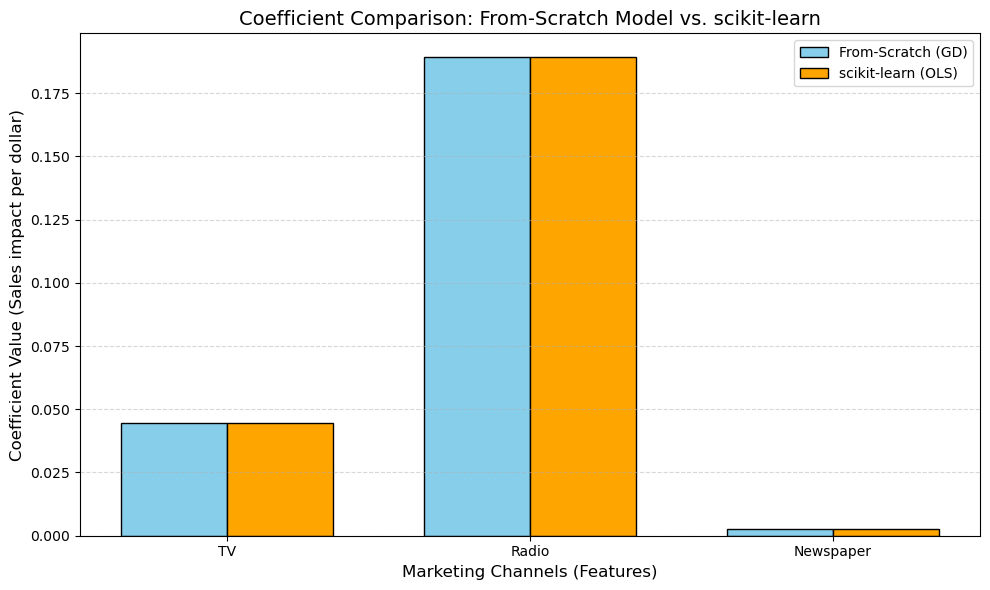

In [36]:
# TODO: write your code here

features = ["TV", "Radio", "Newspaper"]
x_indices = np.arange(len(features))
bar_width = 0.35

scratch_coefficients = [w_original[0], w_original[1], w_original[2]]
sklearn_coefficients = [lr_model.coef_[0], lr_model.coef_[1], lr_model.coef_[2]]

plt.figure(figsize=(10, 6))

plt.bar(
    x_indices - bar_width / 2,
    scratch_coefficients,
    width=bar_width,
    label="From-Scratch (GD)",
    color="skyblue",
    edgecolor="black",
)


plt.bar(
    x_indices + bar_width / 2,
    sklearn_coefficients,
    width=bar_width,
    label="scikit-learn (OLS)",
    color="orange",
    edgecolor="black",
)


plt.title(
    "Coefficient Comparison: From-Scratch Model vs. scikit-learn", fontsize=14
)
plt.xlabel("Marketing Channels (Features)", fontsize=12)
plt.ylabel("Coefficient Value (Sales impact per dollar)", fontsize=12)
plt.xticks(x_indices, features)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


## Step 20: Final Comparison — Metrics Table and Prediction Overlay

- Build a summary DataFrame comparing MAE, MSE, RMSE, R² for both models
- Plot `y_test` against both `y_pred_scratch` and `y_pred_sklearn` on the same scatter plot (different colors/markers) with the diagonal reference line, to visually confirm both models make nearly identical predictions

             FINAL METRICS COMPARISON             
          From-Scratch (GD)  scikit-learn (OLS)
Metric                                         
MAE                 1.46073             1.46076
MSE                 3.17397             3.17410
RMSE                1.78156             1.78160
R² Score            0.89944             0.89944



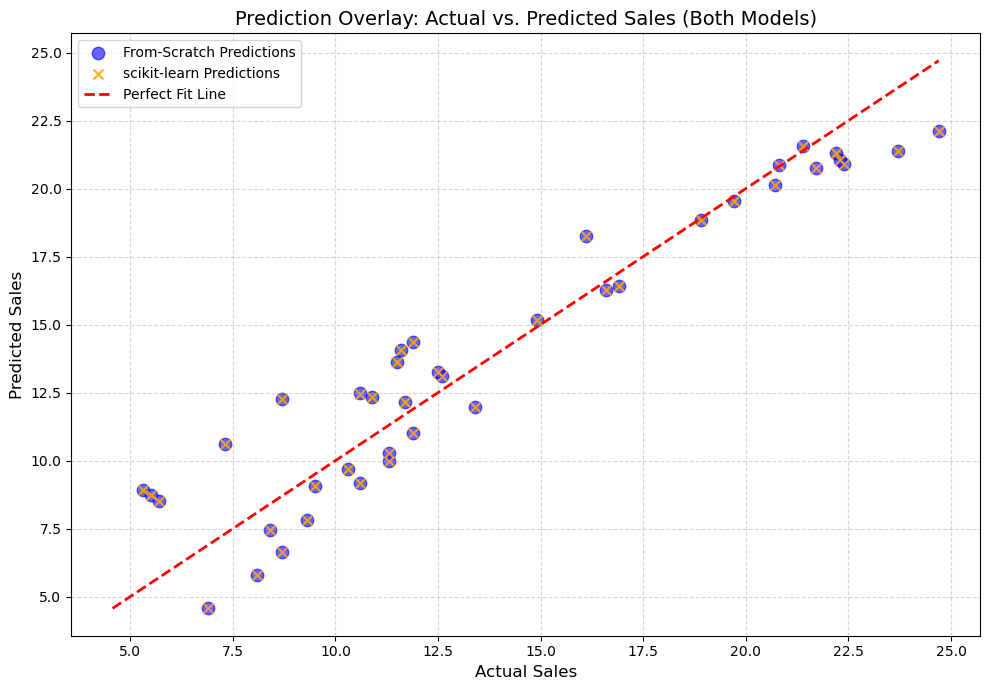

In [37]:
# TODO: write your code here

metrics_data = {
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "From-Scratch (GD)": [mae, mse, rmse, r2],
    "scikit-learn (OLS)": [mae_sk, mse_sk, rmse_sk, r2_sk],
}

df_comparison = pd.DataFrame(metrics_data)

df_comparison.set_index("Metric", inplace=True)

print("=" * 50)
print("             FINAL METRICS COMPARISON             ")
print("=" * 50)
print(df_comparison.round(5))
print("=" * 50 + "\n")


plt.figure(figsize=(10, 7))


plt.scatter(
    y_test,
    y_pred_test,
    color="blue",
    marker="o",
    alpha=0.6,
    s=80,
    label="From-Scratch Predictions",
)


plt.scatter(
    y_test,
    y_pred_sklearn,
    color="orange",
    marker="x",
    alpha=0.9,
    s=50,
    label="scikit-learn Predictions",
)


min_val = min(y_test.min(), y_pred_test.min(), y_pred_sklearn.min())
max_val = max(y_test.max(), y_pred_test.max(), y_pred_sklearn.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit Line",
)


plt.title(
    "Prediction Overlay: Actual vs. Predicted Sales (Both Models)", fontsize=14
)
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()
